 Analyse des Logs Firewall Iptables

## Projet SISE-OPSIE 2026

---

## Objectifs de cette analyse

Ce notebook a pour objectif d’analyser les logs d’un firewall Iptables en environnement Cloud afin de :

1. Nettoyer et structurer les données issues des fichiers de logs bruts.
2. Valider la qualité et la cohérence des informations (IP, ports, protocoles, règles).
3. Identifier les règles firewall les plus utilisées.
4. Analyser la répartition des protocoles et des ports exposés.
5. Étudier le rapprochement entre règles, ports de destination et actions (PERMIT / DENY).
6. Identifier les IP sources les plus actives.
7. Détecter d’éventuels comportements anormaux via une analyse exploratoire avancée.
8. Fournir des éléments d’aide à la décision pour la migration des règles vers un firewall On-Premise (équipe OPSIE).

---

## Contexte

L’analyse porte sur des logs firewall Iptables fournis dans le cadre du projet SISE-OPSIE 2026.  
L’objectif est de produire des métriques de sécurité pertinentes permettant :

- Une meilleure compréhension du trafic réseau observé,
- Une optimisation des règles firewall,
- Une préparation à la phase de simulation et d’analyse avancée (Web App & Machine Learning).


## 0) Cellule — Imports & réglages

In [1]:
import pandas as pd
import numpy as np
import re
from ipaddress import ip_address, ip_network

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 120)

## 1) Cellule — Charger les données

In [2]:
PATH = "data/logs_export.parquet"  

df = pd.read_parquet(PATH)          
df.shape, df.head(3)

((11997652, 1),
                                                                               raw_log
 0    2025-03-20 01:29:24;94.102.61.47;159.84.146.99;TCP;52502;3178;999;DENY;eth0;;6\n
 1  2025-03-20 01:29:25;176.111.174.85;159.84.146.99;TCP;48739;2231;999;DENY;eth0;;6\n
 2    2025-03-20 01:29:27;66.249.65.106;159.84.146.99;TCP;50501;443;1;PERMIT;eth0;;6\n)

## 2) Cellule — Vérifier la structure (ton cas : 1 colonne raw_log)

In [3]:
df.info()
df["raw_log"].head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11997652 entries, 0 to 11997651
Data columns (total 1 columns):
 #   Column   Dtype 
---  ------   ----- 
 0   raw_log  object
dtypes: object(1)
memory usage: 91.5+ MB


0      2025-03-20 01:29:24;94.102.61.47;159.84.146.99;TCP;52502;3178;999;DENY;eth0;;6\n
1    2025-03-20 01:29:25;176.111.174.85;159.84.146.99;TCP;48739;2231;999;DENY;eth0;;6\n
2      2025-03-20 01:29:27;66.249.65.106;159.84.146.99;TCP;50501;443;1;PERMIT;eth0;;6\n
3     2025-03-20 01:29:34;89.248.163.75;159.84.146.99;TCP;43312;8845;999;DENY;eth0;;6\n
4          2025-03-20 01:29:38;42.58.163.244;159.84.146.99;TCP;9746;23;7;DENY;eth0;;6\n
Name: raw_log, dtype: object

## 3) Cellule — Inspecter une ligne complète

In [4]:
sample = df["raw_log"].iloc[0]
sample

'2025-03-20 01:29:24;94.102.61.47;159.84.146.99;TCP;52502;3178;999;DENY;eth0;;6\n'

## 4) Cellule — Compter combien de col

In [5]:
tmp = df["raw_log"].astype(str).str.split(";", expand=True)
tmp.shape, tmp.head(3)

((11997652, 11),
                     0               1              2    3      4     5    6       7     8  9    10
 0  2025-03-20 01:29:24    94.102.61.47  159.84.146.99  TCP  52502  3178  999    DENY  eth0     6\n
 1  2025-03-20 01:29:25  176.111.174.85  159.84.146.99  TCP  48739  2231  999    DENY  eth0     6\n
 2  2025-03-20 01:29:27   66.249.65.106  159.84.146.99  TCP  50501   443    1  PERMIT  eth0     6\n)

## 5) Cellule — Parser raw_log en colonnes

In [6]:
split_df = df["raw_log"].astype(str).str.split(";", expand=True)

## 6) Cellule — Conversion des types + normalisation texte

In [7]:
split_df.columns = [
    "date",          
    "ip_src",        
    "ip_dst",        
    "protocol",      
    "src_port",      
    "dst_port",      
    "rule_id",       
    "action",        
    "in_interface",  
    "out_interface",            
    "fw"  
]

for c in split_df.columns:
    split_df[c] = split_df[c].astype("string").str.strip()

data = split_df.copy()

data["date"] = pd.to_datetime(data["date"], errors="coerce")
data["src_port"] = pd.to_numeric(data["src_port"], errors="coerce")
data["dst_port"] = pd.to_numeric(data["dst_port"], errors="coerce")
data["rule_id"] = pd.to_numeric(data["rule_id"], errors="coerce")
data["fw"] = pd.to_numeric(data["fw"], errors="coerce")

data["protocol"] = data["protocol"].str.upper().str.strip()
data["action"] = data["action"].str.upper().str.strip()
data["in_interface"] = data["in_interface"].str.strip()
data["out_interface"] = data["out_interface"].str.strip()

data.head(3)

,date,ip_src,ip_dst,protocol,src_port,dst_port,rule_id,action,in_interface,out_interface,fw
0,2025-03-20 01:29:24,94.102.61.47,159.84.146.99,TCP,52502.0,3178.0,999.0,DENY,eth0,,6.0
1,2025-03-20 01:29:25,176.111.174.85,159.84.146.99,TCP,48739.0,2231.0,999.0,DENY,eth0,,6.0
2,2025-03-20 01:29:27,66.249.65.106,159.84.146.99,TCP,50501.0,443.0,1.0,PERMIT,eth0,,6.0


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11997652 entries, 0 to 11997651
Data columns (total 11 columns):
 #   Column         Dtype         
---  ------         -----         
 0   date           datetime64[ns]
 1   ip_src         string        
 2   ip_dst         string        
 3   protocol       string        
 4   src_port       Float64       
 5   dst_port       Float64       
 6   rule_id        Float64       
 7   action         string        
 8   in_interface   string        
 9   out_interface  string        
 10  fw             Float64       
dtypes: Float64(4), datetime64[ns](1), string(6)
memory usage: 1.0 GB


## 7) Cellule — Nettoyage IP (valider format IPv4/IPv6)

In [9]:
def is_valid_ip(x):
    try:
        ip_address(str(x))
        return True
    except Exception:
        return False

for col in ["ip_src", "ip_dst"]:
    if col in data.columns:
        valid = data[col].apply(is_valid_ip)
        print(col, "invalid rate:", float((~valid).mean()))
        data.loc[~valid, col] = pd.NA

data.head(3)

ip_src invalid rate: 6.667971366397358e-07
ip_dst invalid rate: 6.667971366397358e-07


,date,ip_src,ip_dst,protocol,src_port,dst_port,rule_id,action,in_interface,out_interface,fw
0,2025-03-20 01:29:24,94.102.61.47,159.84.146.99,TCP,52502.0,3178.0,999.0,DENY,eth0,,6.0
1,2025-03-20 01:29:25,176.111.174.85,159.84.146.99,TCP,48739.0,2231.0,999.0,DENY,eth0,,6.0
2,2025-03-20 01:29:27,66.249.65.106,159.84.146.99,TCP,50501.0,443.0,1.0,PERMIT,eth0,,6.0


Les adresses IP sources et destinations ont été validées à l’aide du module `ipaddress`.  
Le taux d’adresses invalides est extrêmement faible (~6.6e-07), ce qui indique une excellente qualité des données brutes.


## 8) Cellule — Filtrer la période demandée (nov 2025 → fév 2026)

In [10]:
start = pd.Timestamp("2025-11-01 00:00:00")
end   = pd.Timestamp("2026-02-28 23:59:59")

before = len(data)
data = data[(data["date"] >= start) & (data["date"] <= end)]
after = len(data)

before, after, data["date"].min(), data["date"].max()

(11997652,
 4572903,
 Timestamp('2025-11-12 09:56:37'),
 Timestamp('2026-02-12 10:08:39'))

In [11]:
data["date"].min(), data["date"].max()

(Timestamp('2025-11-12 09:56:37'), Timestamp('2026-02-12 10:08:39'))

## 9) Cellule — Supprimer FW=6 si présent

In [12]:
# On supprime juste la colonne fw
data = data.drop(columns=["fw"], errors="ignore")

len(data), data.head(3)

(4572903,
                        date         ip_src         ip_dst protocol  src_port  dst_port  rule_id  action in_interface out_interface
 7424749 2025-11-12 09:56:37   77.90.185.64  159.84.146.99      TCP   55366.0   65153.0    999.0    DENY         eth0              
 7424750 2025-11-12 09:56:37  47.128.20.252  159.84.146.99      TCP   14436.0     443.0      1.0  PERMIT         eth0              
 7424751 2025-11-12 09:56:38   23.22.35.162  159.84.146.99      TCP   55973.0     443.0      1.0  PERMIT         eth0              )

## 10) Cellule — Contrôles qualité

In [13]:
def quick_profile(df):
    out = []
    for col in df.columns:
        out.append({
            "col": col,
            "dtype": str(df[col].dtype),
            "missing_rate": float(df[col].isna().mean()),
            "n_unique": int(df[col].nunique(dropna=True))
        })
    return pd.DataFrame(out).sort_values("missing_rate", ascending=False)

quick_profile(data).head(30)

,col,dtype,missing_rate,n_unique
0,date,datetime64[ns],0.0,3106616
1,ip_src,string,0.0,130849
2,ip_dst,string,0.0,1
3,protocol,string,0.0,1
4,src_port,Float64,0.0,64566
5,dst_port,Float64,0.0,65532
6,rule_id,Float64,0.0,10
7,action,string,0.0,2
8,in_interface,string,0.0,1
9,out_interface,string,0.0,1



### Contrôles qualité globaux

L’analyse de la qualité des données montre :

- Aucune valeur manquante significative
- Types correctement convertis (datetime, numériques, string)
- 10 règles distinctes
- 2 actions distinctes (PERMIT / DENY)
- Une destination principale fortement sollicitée

## Analyses demandées

## 11) Cellule — Top règles les plus utilisées

In [14]:
top_rules = data["rule_id"].value_counts(dropna=True).head(30).reset_index()
top_rules.columns = ["rule_id", "count"]
top_rules

,rule_id,count
0,1.0,3660700
1,999.0,755909
2,7.0,38074
3,4.0,32834
4,8.0,32827
5,6.0,24709
6,9.0,7642
7,2.0,7642
8,5.0,6656
9,11.0,5910


### Classement des règles les plus utilisées

L’analyse du volume par `rule_id` montre une forte concentration du trafic sur quelques règles principales.

La règle 1 est très majoritaire, suivie par la règle 999.

**Interprétation sécurité :**

- La règle 1 semble correspondre à une règle autorisant un service critique (probablement HTTPS).
- La règle 999 apparaît corrélée aux actions de type DENY, ce qui suggère une règle de nettoyage globale ("cleanup rule").
- Une forte concentration sur peu de règles peut indiquer une configuration simple mais peu granulaire.

## 12) Cellule — Répartition des protocoles (histogramme)

In [15]:
proto_counts = data["protocol"].value_counts(dropna=True).reset_index()
proto_counts.columns = ["protocol", "count"]
proto_counts

,protocol,count
0,TCP,4572903


### Répartition des protocoles

Le trafic observé est exclusivement TCP.

**Interprétation :**

- L’absence d’UDP suggère que les services analysés sont principalement orientés vers des protocoles applicatifs TCP (HTTP, HTTPS, SSH, etc.).
- Cela peut indiquer un environnement web ou applicatif centralisé.

Le firewall semble configuré pour protéger principalement des services TCP.

## 13) Cellule — Top 10 règles UDP

In [16]:
top_udp = (
    data[data["protocol"] == "UDP"]["rule_id"]
    .value_counts(dropna=True)
    .head(10)
    .reset_index()
)
top_udp.columns = ["rule_id", "count"]
top_udp

,rule_id,count


- Aucun trafic UDP significatif n’a été observé.

## 14) Cellule — Top 5 règles TCP

In [17]:
top_tcp = (
    data[data["protocol"] == "TCP"]["rule_id"]
    .value_counts(dropna=True)
    .head(5)
    .reset_index()
)
top_tcp.columns = ["rule_id", "count"]
top_tcp

,rule_id,count
0,1.0,3660700
1,999.0,755909
2,7.0,38074
3,4.0,32834
4,8.0,32827


In [31]:
top_tcp_rules = (
    data[data["protocol"] == "TCP"]["rule_id"]
    .value_counts()
    .head(5)
    .index
    .tolist()
)

top_tcp_rules

[1.0, 999.0, 7.0, 4.0, 8.0]

In [34]:
main_ports_per_rule = (
    top_tcp_ports
    .groupby("rule_id")
    .first()
    .reset_index()
)

main_ports_per_rule

,rule_id,dst_port,count
0,1.0,443.0,3621944
1,4.0,22.0,32834
2,7.0,23.0,38074
3,8.0,22.0,32827
4,999.0,8080.0,7129


### Interprétation – Ports principaux associés aux règles TCP dominantes

L’analyse des 5 règles TCP les plus utilisées met en évidence les associations suivantes :

- **Rule 1 → Port 443 (HTTPS)**  
- **Rule 4 → Port 22 (SSH)**  
- **Rule 7 → Port 23 (Telnet)**  
- **Rule 8 → Port 22 (SSH)**  
- **Rule 999 → Port 8080 (HTTP alternatif, majoritairement en DENY)**  

#### Analyse sécurité :

La règle 1 est massivement associée au port 443, ce qui confirme que le trafic principal concerne un service HTTPS central.  
Les règles 4 et 8 concernent le port 22 (SSH), indiquant une exposition du service d’administration à surveiller attentivement.

La présence du port 23 (Telnet) dans les règles dominantes est notable : bien que ce protocole soit obsolète et peu sécurisé, il semble être explicitement géré par la politique firewall.

Enfin, la règle 999 associée au port 8080 apparaît majoritairement en action DENY, suggérant un mécanisme de rejet pour les services HTTP alternatifs non autorisés.

#### Conclusion :

La politique firewall semble structurée autour :

- D’un service HTTPS principal (443)
- D’un accès SSH contrôlé (22)
- D’un blocage explicite de services non sécurisés (23, 8080)

## 15) Cellule — Rapprochement rule_id ↔ dst_port ↔ action (TCP)

In [18]:
tcp = data[data["protocol"] == "TCP"].copy()

rule_port_action = (
    tcp.groupby(["rule_id", "dst_port", "action"], dropna=True)
       .size()
       .reset_index(name="count")
       .sort_values("count", ascending=False)
)

rule_port_action.head(50)

,rule_id,dst_port,action,count
1,1.0,443.0,PERMIT,3621944
0,1.0,80.0,PERMIT,38756
9,7.0,23.0,DENY,38074
3,4.0,22.0,PERMIT,32834
10,8.0,22.0,PERMIT,32827
7,6.0,445.0,DENY,20301
11,9.0,3306.0,PERMIT,7642
2,2.0,3306.0,PERMIT,7642
8079,999.0,8080.0,DENY,7129
5,5.0,21.0,DENY,6076


In [48]:
import pandas as pd
import plotly.graph_objects as go

# 1) On garde les 20 plus gros flux
flows = rule_port_action.head(20).copy()

flows["rule_id"] = flows["rule_id"].astype(int).astype(str)
flows["dst_port"] = flows["dst_port"].astype(int).astype(str)

# 2) Nœuds : règles + ports + actions
left_nodes  = ["R" + r for r in flows["rule_id"].unique()]
mid_nodes   = ["P" + p for p in flows["dst_port"].unique()]
right_nodes = ["A" + a for a in flows["action"].unique()]

nodes = left_nodes + mid_nodes + right_nodes
node_index = {name: i for i, name in enumerate(nodes)}

# 3) Liens : rule -> port, puis port -> action
rule_to_port = (
    flows.groupby(["rule_id", "dst_port"], as_index=False)["count"].sum()
)
port_to_action = (
    flows.groupby(["dst_port", "action"], as_index=False)["count"].sum()
)

sources = []
targets = []
values  = []

for _, row in rule_to_port.iterrows():
    sources.append(node_index["R" + row["rule_id"]])
    targets.append(node_index["P" + row["dst_port"]])
    values.append(int(row["count"]))

for _, row in port_to_action.iterrows():
    sources.append(node_index["P" + row["dst_port"]])
    targets.append(node_index["A" + row["action"]])
    values.append(int(row["count"]))

# 4) Labels affichés
labels = (
    [f"Rule {r}" for r in flows["rule_id"].unique()] +
    [f"Port {p}" for p in flows["dst_port"].unique()] +
    [f"Action {a}" for a in flows["action"].unique()]
)

fig = go.Figure(
    data=[go.Sankey(
        node=dict(label=labels, pad=12, thickness=14),
        link=dict(source=sources, target=targets, value=values)
    )]
)
fig.update_layout(title="Flux Rule → Port → Action (Top 20)", font_size=12)
fig.show()

### Analyse des flux Rule → Port → Action (TCP)

Le diagramme met en évidence une forte concentration du trafic autour de la règle 1 associée au port 443 (HTTPS), majoritairement en action PERMIT.  
Ce flux représente la quasi-totalité du trafic autorisé observé.

Les flux secondaires révèlent :

- Une exposition contrôlée du port 22 (SSH),
- La gestion explicite de ports sensibles tels que 23 (Telnet) et 445 (SMB),
- Une règle 999 jouant le rôle de règle de rejet globale (DENY), interceptant divers ports non autorisés (8080, 8728, 587, etc.).

On observe une asymétrie marquée entre les flux PERMIT et DENY :  
le trafic autorisé est concentré sur des services spécifiques, tandis que les rejets sont distribués sur une variété de ports.

Cette structure confirme une politique de filtrage cohérente basée sur le principe :
**"deny by default" avec ouverture ciblée des services essentiels.**

## 16) Cellule — Graphiques Matplotlib

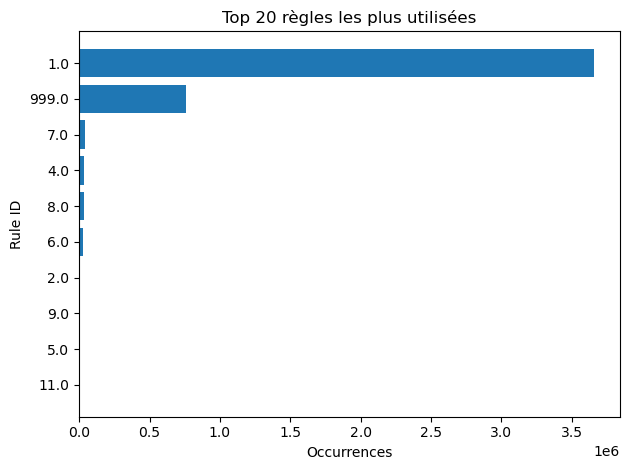

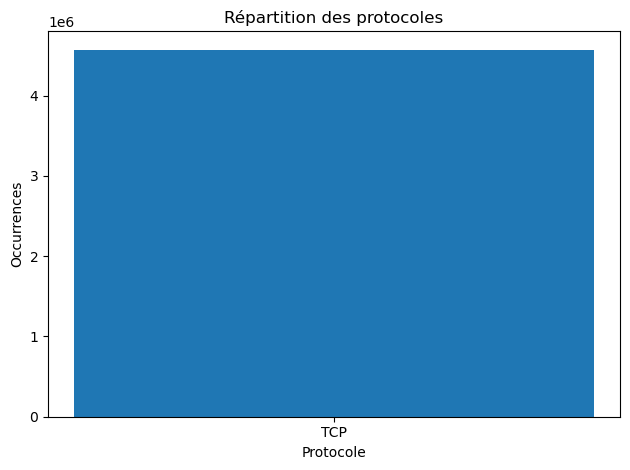

In [19]:
import matplotlib.pyplot as plt

# Top 20 rules
plt.figure()
top20 = top_rules.head(20).sort_values("count")
plt.barh(top20["rule_id"].astype(str), top20["count"])
plt.title("Top 20 règles les plus utilisées")
plt.xlabel("Occurrences")
plt.ylabel("Rule ID")
plt.tight_layout()
plt.show()

# Protocoles
plt.figure()
plt.bar(proto_counts["protocol"].astype(str), proto_counts["count"])
plt.title("Répartition des protocoles")
plt.xlabel("Protocole")
plt.ylabel("Occurrences")
plt.tight_layout()
plt.show()

## 17) Cellule — Features par IP source

In [20]:
feat = data.groupby("ip_src").agg(
    events=("ip_src", "size"),
    uniq_dst=("ip_dst", "nunique"),
    uniq_ports=("dst_port", "nunique"),
    tcp_events=("protocol", lambda s: int((s == "TCP").sum())),
    udp_events=("protocol", lambda s: int((s == "UDP").sum())),
).reset_index()

feat["tcp_ratio"] = feat["tcp_events"] / feat["events"]
feat["udp_ratio"] = feat["udp_events"] / feat["events"]

feat.sort_values("events", ascending=False).head(10)

,ip_src,events,uniq_dst,uniq_ports,tcp_events,udp_events,tcp_ratio,udp_ratio
67186,3.224.220.101,773605,1,2,773605,0,1.0,0.0
65157,23.22.35.162,762887,1,2,762887,0,1.0,0.0
109400,52.70.240.171,687748,1,2,687748,0,1.0,0.0
108593,51.79.181.158,68722,1,64415,68722,0,1.0,0.0
3336,103.89.91.86,61109,1,57681,61109,0,1.0,0.0
2688,103.151.123.241,60630,1,57593,60630,0,1.0,0.0
2577,103.139.44.2,49874,1,49874,49874,0,1.0,0.0
127461,89.248.165.166,34097,1,34092,34097,0,1.0,0.0
65201,23.230.171.181,31143,1,31138,31143,0,1.0,0.0
123295,77.90.185.64,27115,1,26867,27115,0,1.0,0.0


## 18) Cellule — Ajouter un signal “ports sensibles” (<1024)

In [21]:
# proportion d'événements vers ports <1024
tmp = data.copy()
tmp["is_privileged_port"] = (tmp["dst_port"] < 1024)

feat2 = tmp.groupby("ip_src").agg(
    priv_port_events=("is_privileged_port", "sum"),
    priv_port_ratio=("is_privileged_port", "mean"),
).reset_index()

feat = feat.merge(feat2, on="ip_src", how="left")
feat.head()

,ip_src,events,uniq_dst,uniq_ports,tcp_events,udp_events,tcp_ratio,udp_ratio,priv_port_events,priv_port_ratio
0,1.0.158.106,1,1,1,1,0,1.0,0.0,1,1.0
1,1.0.159.170,1,1,1,1,0,1.0,0.0,1,1.0
2,1.0.169.38,1,1,1,1,0,1.0,0.0,0,0.0
3,1.0.218.2,1,1,1,1,0,1.0,0.0,1,1.0
4,1.0.229.25,3,1,1,3,0,1.0,0.0,3,1.0


## 19) Cellule — Feature “burst” temporel (activité dense)

In [22]:
t = data[["ip_src", "date"]].dropna().copy()
t["minute"] = t["date"].dt.floor("min")

per_min = t.groupby(["ip_src", "minute"]).size().reset_index(name="events_per_min")
burst = per_min.groupby("ip_src")["events_per_min"].max().reset_index(name="max_events_per_min")

feat = feat.merge(burst, on="ip_src", how="left").fillna({"max_events_per_min": 0})
feat.sort_values("max_events_per_min", ascending=False).head(10)

,ip_src,events,uniq_dst,uniq_ports,tcp_events,udp_events,tcp_ratio,udp_ratio,priv_port_events,priv_port_ratio,max_events_per_min
676,10.39.112.19,2012,1,998,2012,0,1.0,0.0,320,0.159046,2012
30825,159.84.186.206,2010,1,999,2010,0,1.0,0.0,318,0.158209,2008
67186,3.224.220.101,773605,1,2,773605,0,1.0,0.0,773605,1.0,772
109400,52.70.240.171,687748,1,2,687748,0,1.0,0.0,687748,1.0,757
6136,106.57.254.2,749,1,362,749,0,1.0,0.0,149,0.198932,749
20871,123.150.138.194,745,1,360,745,0,1.0,0.0,147,0.197315,745
65157,23.22.35.162,762887,1,2,762887,0,1.0,0.0,762887,1.0,725
113697,54.87.181.181,367,1,1,367,0,1.0,0.0,367,1.0,367
109823,52.91.74.3,364,1,1,364,0,1.0,0.0,364,1.0,364
44686,18.234.31.141,365,1,1,365,0,1.0,0.0,365,1.0,348


### Analyse d’activité dense ("burst")

Une feature de type "burst temporel" a été calculée afin d’identifier les IP présentant des pics d’activité par minute.

Certaines IP dépassent plusieurs centaines voire milliers d’événements par minute.

**Interprétation :**

Cela peut correspondre :

- À du trafic applicatif massif légitime
- Ou à une tentative de scan ou d’abus applicatif

Ce signal sera exploité dans la phase de détection d’anomalies.

## 20) Cellule — Modèle

In [23]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

features_cols = ["events", "uniq_dst", "uniq_ports", "tcp_ratio", "udp_ratio", "priv_port_ratio", "max_events_per_min"]
X = feat[features_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

scaler = StandardScaler()
Xn = scaler.fit_transform(X)

iso = IsolationForest(
    n_estimators=400,
    contamination=0.02,  # ~2% anomalies 
    random_state=42
)

feat["is_anomaly"] = (iso.fit_predict(Xn) == -1)
feat["anomaly_score_raw"] = iso.score_samples(Xn)  # plus bas = plus suspect

suspects = feat.sort_values("anomaly_score_raw").head(30)
suspects

,ip_src,events,uniq_dst,uniq_ports,tcp_events,udp_events,tcp_ratio,udp_ratio,priv_port_events,priv_port_ratio,max_events_per_min,is_anomaly,anomaly_score_raw
108593,51.79.181.158,68722,1,64415,68722,0,1.0,0.0,0,0.0,100,True,-0.860097
108597,51.79.191.240,13178,1,13103,13178,0,1.0,0.0,0,0.0,124,True,-0.859952
3336,103.89.91.86,61109,1,57681,61109,0,1.0,0.0,0,0.0,91,True,-0.859807
2688,103.151.123.241,60630,1,57593,60630,0,1.0,0.0,0,0.0,66,True,-0.857918
123295,77.90.185.64,27115,1,26867,27115,0,1.0,0.0,374,0.013793,53,True,-0.855165
2577,103.139.44.2,49874,1,49874,49874,0,1.0,0.0,0,0.0,48,True,-0.854442
676,10.39.112.19,2012,1,998,2012,0,1.0,0.0,320,0.159046,2012,True,-0.853864
30825,159.84.186.206,2010,1,999,2010,0,1.0,0.0,318,0.158209,2008,True,-0.853864
6136,106.57.254.2,749,1,362,749,0,1.0,0.0,149,0.198932,749,True,-0.851269
20871,123.150.138.194,745,1,360,745,0,1.0,0.0,147,0.197315,745,True,-0.849974


### Détection d’anomalies (Isolation Forest)

Un modèle Isolation Forest a été entraîné sur des features comportementales :

- Nombre total d’événements
- Diversité des ports
- Diversité des destinations
- Ratio TCP/UDP
- Ratio de ports sensibles
- Burst maximal par minute

Certaines IP ont été identifiées comme suspectes.

**Interprétation :**

Les IP suspectes présentent :

- Un volume important
- Une activité concentrée sur un seul service
- Des pics d’activité significatifs

Ces comportements peuvent correspondre à des scans, tentatives de brute force ou abus applicatifs.

## 21) Cellule — Lire les “suspects”

In [24]:
sus_ip = suspects["ip_src"].head(5).tolist()
sus_ip

['51.79.181.158',
 '51.79.191.240',
 '103.89.91.86',
 '103.151.123.241',
 '77.90.185.64']

In [25]:
data[data["ip_src"].isin(sus_ip)].head(30)

,date,ip_src,ip_dst,protocol,src_port,dst_port,rule_id,action,in_interface,out_interface
7424749,2025-11-12 09:56:37,77.90.185.64,159.84.146.99,TCP,55366.0,65153.0,999.0,DENY,eth0,
7424867,2025-11-12 09:58:38,77.90.185.64,159.84.146.99,TCP,55366.0,65353.0,999.0,DENY,eth0,
7424891,2025-11-12 09:59:21,77.90.185.64,159.84.146.99,TCP,55366.0,697.0,999.0,DENY,eth0,
7425045,2025-11-12 10:02:31,77.90.185.64,159.84.146.99,TCP,55366.0,61686.0,999.0,DENY,eth0,
7425060,2025-11-12 10:02:44,77.90.185.64,159.84.146.99,TCP,55366.0,3623.0,999.0,DENY,eth0,
7425087,2025-11-12 10:03:18,77.90.185.64,159.84.146.99,TCP,55366.0,62410.0,999.0,DENY,eth0,
7425089,2025-11-12 10:03:19,77.90.185.64,159.84.146.99,TCP,55366.0,62977.0,999.0,DENY,eth0,
7425218,2025-11-12 10:06:11,77.90.185.64,159.84.146.99,TCP,55366.0,61106.0,999.0,DENY,eth0,
7425372,2025-11-12 10:09:24,77.90.185.64,159.84.146.99,TCP,55366.0,62602.0,999.0,DENY,eth0,
7425382,2025-11-12 10:09:36,77.90.185.64,159.84.146.99,TCP,55366.0,60952.0,999.0,DENY,eth0,


## 22) Cellule — Définir le plan d’adressage

In [26]:
allowed_networks = [
    ip_network("10.0.0.0/8"),
    ip_network("172.16.0.0/12"),
    ip_network("192.168.0.0/16"),
]

def in_allowed_ranges(ip):
    try:
        ipobj = ip_address(str(ip))
        return any(ipobj in net for net in allowed_networks)
    except Exception:
        return False

data["ip_src_in_plan"] = data["ip_src"].apply(in_allowed_ranges)
outside = data[~data["ip_src_in_plan"]].copy()

outside[["date", "ip_src", "ip_dst", "protocol", "dst_port", "action", "rule_id"]].head(20)

,date,ip_src,ip_dst,protocol,dst_port,action,rule_id
7424749,2025-11-12 09:56:37,77.90.185.64,159.84.146.99,TCP,65153.0,DENY,999.0
7424750,2025-11-12 09:56:37,47.128.20.252,159.84.146.99,TCP,443.0,PERMIT,1.0
7424751,2025-11-12 09:56:38,23.22.35.162,159.84.146.99,TCP,443.0,PERMIT,1.0
7424752,2025-11-12 09:56:39,79.124.60.150,159.84.146.99,TCP,56283.0,DENY,999.0
7424753,2025-11-12 09:56:39,47.128.20.252,159.84.146.99,TCP,443.0,PERMIT,1.0
7424754,2025-11-12 09:56:39,47.128.20.252,159.84.146.99,TCP,443.0,PERMIT,1.0
7424755,2025-11-12 09:56:39,47.128.20.252,159.84.146.99,TCP,443.0,PERMIT,1.0
7424756,2025-11-12 09:56:39,47.128.20.252,159.84.146.99,TCP,443.0,PERMIT,1.0
7424757,2025-11-12 09:56:39,47.128.20.252,159.84.146.99,TCP,443.0,PERMIT,1.0
7424758,2025-11-12 09:56:40,76.33.9.128,159.84.146.99,TCP,443.0,PERMIT,1.0


### Analyse du plan d’adressage

Les IP hors des plages privées RFC1918 ont été identifiées.

La majorité des IP suspectes sont externes, ce qui est cohérent avec :

- Du trafic Internet
- Des tentatives d’accès externes

Cela confirme que la surface d’attaque principale provient de l’extérieur.

## 23) Cellule — TOP 5 IP sources les plus émettrices

In [27]:
top5_ip = data["ip_src"].value_counts(dropna=True).head(5).reset_index()
top5_ip.columns = ["ip_src", "count"]
top5_ip

,ip_src,count
0,3.224.220.101,773605
1,23.22.35.162,762887
2,52.70.240.171,687748
3,51.79.181.158,68722
4,103.89.91.86,61109


### Analyse comportementale des IP sources

####  Top 5 IP les plus émettrices

Certaines IP présentent un volume extrêmement élevé d’événements.

**Interprétation :**

- Les IP les plus actives communiquent principalement avec une seule destination.
- Cela peut correspondre à des serveurs applicatifs ou reverse proxy.
- Toutefois, un volume élevé ne signifie pas absence de risque.

Une analyse comportementale complémentaire est nécessaire.

## 24) Cellule — TOP 10 ports <1024 avec accès autorisé

In [28]:
data["action"].value_counts(dropna=True).head(20)

action
PERMIT    3747555
DENY       825348
Name: count, dtype: Int64

In [29]:
allowed_actions = {"PERMIT"}

tmp = data.copy()
tmp["is_allowed"] = tmp["action"].isin(allowed_actions)

top10_priv_allowed = (
    tmp[(tmp["dst_port"] < 1024) & (tmp["is_allowed"])]
    ["dst_port"]
    .value_counts(dropna=True)
    .head(10)
    .reset_index()
)
top10_priv_allowed.columns = ["dst_port", "count"]
top10_priv_allowed

,dst_port,count
0,443.0,3621944
1,22.0,65661
2,80.0,38756
3,110.0,5910


### Analyse des ports privilégiés (<1024)

Les ports privilégiés les plus utilisés avec accès autorisé sont :

- 443 (HTTPS)
- 22 (SSH)
- 80 (HTTP)
- 110 (POP3)

**Analyse sécurité :**

- Le port 443 domine largement, indiquant un service HTTPS central.
- Le port 22 (SSH) représente une surface d’exposition critique.
- La présence du port 80 peut indiquer un service HTTP non chiffré ou redirection vers HTTPS.
- Le port 110 (POP3) peut correspondre à un service legacy exposé.

Les ports 22 et 80 devront faire l’objet d’une vigilance particulière lors de la migration OPSIE.

In [30]:
data.to_parquet("data/clean_logs_nov2025_feb2026.parquet", index=False)
feat.to_csv("data/features_by_ip.csv", index=False)
suspects.to_csv("data/top_suspects_ip.csv", index=False)

print("Exports OK ")

Exports OK 
